---
title: "Module 05: Lab 02"
subtitle: "Regression Modeling on Employment Data"
author:
  - name: Shangxuan Zhong
    affiliations:
      - id: cmu
        name: Boston University
        city: Boston
        state: MA
number-sections: true
date: "2025-04-11"
format:
  html:
    theme: cerulean
    toc: true
    toc-depth: 2
date-modified: today
date-format: long
execute: 
  echo: false
  eval: false
  freeze: auto
---

# Objectives {.unnumbered}

1. Use **PySpark** to process the Lightcast dataset.
2. Engineer features from structured columns for salary prediction.
3. Train **Linear Regression model**.
4. Evaluate models using **RMSE** and **R²**.
5. Visualize predictions using diagnostic plots.
6. Push work to GitHub and submit the repository link.

# Setup {.unnumbered}

The instruction below provides you with general keywords for columns used in the lightcast file. See the data schema generated after the load dataset code above to use proper column name. For visualizations, tables, or summaries, please **customize colors, fonts, and styles** as appropriate to avoid a **2.5-point deduction**. Also, **provide a two-sentence explanation** describing key insights drawn from each section's code and outputs. 

1. Follow the steps below as necessary, use your best judgement in importing/installing/creating/saving files as needed.
2. Create a new Jupyter Notebook in your `ad688-sp25-lab08` directory named `lab08_yourname.ipynb`, if the file exists make sure to change the name.
3. Use your **EC2 instance** for this lab.
4. Ensure the `lightcast_data.csv` file is available on the EC2 instance. if not then **Download the dataset**
5. **Add the dataset to `.gitignore`** to avoid pushing large files to GitHub. Open your `.gitignore` file and add:
6. Make sure to create a virtual environment and install the required Python libraries if needed, don't forget to activate it:
7. Install the required Python libraries if needed, you can also use the given requirement file to install the packages to the virtual environment:

```bash
python3 -m venv .venv
source .venv/bin/activate
gdown https://drive.google.com/uc?id=1V2GCHGt2dkFGqVBeoUFckU4IhUgk4ocQ
echo "lightcast_job_postings.csv" >> .gitignore
pip install -r requirements.txt
```


# Load the Dataset
1. **Load the Raw Dataset**:
   - Use Pyspark to the `lightcast_data.csv` file into a DataFrame:
   - You can reuse the previous code. 
   - [Copying code from your friend constitutes plagiarism. DO NOT DO THIS]{.uured-bold}.

In [ ]:
#| eval: true
#| echo: true
from pyspark.sql import SparkSession
import plotly.io as pio
pio.renderers.default = "notebook"

# Initialize Spark Session
spark = SparkSession.builder.appName("LightcastData").getOrCreate()

# Load Data
df = spark.read.option("header", "true").option("inferSchema", "true").option("multiLine","true").option("escape", "\"").csv("./data/lightcast_job_postings.csv")

# Show Schema and Sample Data
print("---This is Diagnostic check, No need to print it in the final doc---")

df.printSchema() # comment this line when rendering the submission
df.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/14 01:44:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---This is Diagnostic check, No need to print it in the final doc---
root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATIO

25/04/14 01:44:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+-----------------+----------------------+----------+--------+---------+--------+--------------------+--------------------+--------------------+-----------+-------------------+--------------------+--------------------+---------------+----------------+--------+--------------------+-----------+-------------------+----------------+---------------------+-------------+-------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+------+-----------+----------------+-------------------+---------+-----------+--------------------+--------------------+-------------+------+--------------+-----+--------------------+-----+----------+---------------+--------------------+---------------+--------------------+------------+--------------------+------------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+------

# Feature Engineering

Feature Engineering is a crucial step in preparing your data for machine learning. In this lab, we will focus on the following tasks:

1. **Drop rows with missing values** in the target variable and key features.
2. By now you are already familiar with the code and the data. Based on your understanding please choose any 3 (my code output has 10) variables as:
   1. two continuous variables (use your best judgment!)
   2. one categorical.
   3. Your dependent variable (y) is `SALARY`.
3. **Convert categorical variables** into numerical representations using **StringIndexer** and **OneHotEncoder**.
4. **Assemble features** into a single vector using **VectorAssembler**.
5. **Split the data** into training and testing sets.

In [ ]:
#| eval: false
#| echo: true
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Drop rows with nulls in target and selected features
df = df.dropna(subset=["SALARY", "DURATION", "MODELED_DURATION", "EMPLOYMENT_TYPE_NAME"])

# Categorical column
categorical_cols = ["EMPLOYMENT_TYPE_NAME"]

# Index and encode categorical variable
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid='skip') for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_vec") for col in categorical_cols]

# Assemble all features
assembler = VectorAssembler(
    inputCols=["DURATION", "MODELED_DURATION"] + [f"{col}_vec" for col in categorical_cols],
    outputCol="features"
)

# Pipeline to handle transformations
pipeline = Pipeline(stages=indexers + encoders + [assembler])

# Transform the data
data = pipeline.fit(df).transform(df)

# Show sample data
data.select("features", "SALARY").show(5, False)

+-------------------+------+
|features           |SALARY|
+-------------------+------+
|[15.0,15.0,0.0,0.0]|92500 |
|[10.0,10.0,1.0,0.0]|110155|
|[55.0,55.0,1.0,0.0]|192800|
|[18.0,18.0,1.0,0.0]|125900|
|[10.0,10.0,1.0,0.0]|110155|
+-------------------+------+
only showing top 5 rows



# Train/Test Split

- Perform a **random split** of the data into training and testing sets.
- Set a random seed for reproducibility.
- You can choose a number for splitting to your liking, justify your choice.

In [3]:
#| eval: true
#| echo: false
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)
print((train_data.count(), len(train_data.columns)))
print((test_data.count(), len(test_data.columns)))

(12636, 134)


(3082, 134)


# Linear Regression

- Train a **Linear Regression** model using the training data. [You will run in to an important issue here. Please make an effort in figuring it by yourself. This is one of the most asked interview questions in CapitalOne's management recruiting program.]{.uured-bold}
- Evaluate the model on the test data.
- Print the coefficients, intercept, R², RMSE, and MAE.
- Use the `summary` object to extract the coefficients and their standard errors, t-values, and p-values.
- Create a DataFrame to display the coefficients, standard errors, t-values, p-values, and confidence intervals.
- Interpret the coefficients and their significance and explain the model performance metrics.

In [ ]:
#| eval: false
#| echo: false
from pyspark.ml.regression import LinearRegression

# Train the Linear Regression Model
lr = LinearRegression(featuresCol="features", labelCol="SALARY")
lr_model = lr.fit(train_data)
summary = lr_model.summary

# Evaluate the model on the test data
test_results = lr_model.evaluate(test_data)

# Coefficients and Intercept
print("Intercept: {:.4f}".format(lr_model.intercept))
print("Coefficients:")
for i, coef in enumerate(lr_model.coefficients):
    print(f"  Feature {i + 1}: {coef:.4f}")

# Regression Summary
print("\n--- Regression Summary ---")
print("Coefficient Standard Errors:", [f"{val:.4f}" for val in summary.coefficientStandardErrors])
print("T Values:", [f"{val:.4f}" for val in summary.tValues])
print("P Values:", [f"{val:.4f}" for val in summary.pValues])

print(f"R² (Training): {summary.r2:.4f}")
print(f"RMSE (Test): {test_results.rootMeanSquaredError:.4f}")
print(f"MAE (Test): {test_results.meanAbsoluteError:.4f}")

# Prepare Full Summary Table
# Get feature names
feature_names = [f"feature_{i+1}" for i in range(len(lr_model.coefficients))]
features = ["Intercept"] + feature_names
coefs = [lr_model.intercept] + list(lr_model.coefficients)

# Extract stats from summary
se = summary.coefficientStandardErrors
tvals = summary.tValues
pvals = summary.pValues

# Compute 95% confidence intervals
z = 1.96  # for 95% CI
ci_lower = [c - z * e if e is not None else None for c, e in zip(coefs, se)]
ci_upper = [c + z * e if e is not None else None for c, e in zip(coefs, se)]


print("Feature names:", len(features))
print("Coefficients:", len(coefs))
print("Standard Errors:", len(se))
print("t-values:", len(tvals))
print("p-values:", len(pvals))
print("ci_lower:", len(ci_lower))
print("ci_upper:", len(ci_upper))

25/04/14 01:45:56 WARN Instrumentation: [e9ae186b] regParam is zero, which might cause numerical instability and overfitting.


Intercept: 95051.1276
Coefficients:
  Feature 1: -117.5186
  Feature 2: 158.1269
  Feature 3: 19821.5310
  Feature 4: 4825.9514

--- Regression Summary ---
Coefficient Standard Errors: ['47.9572', '52.3795', '2913.4479', '3595.6836', '2952.8720']
T Values: ['-2.4505', '3.0189', '6.8035', '1.3422', '32.1894']
P Values: ['0.0143', '0.0025', '0.0000', '0.1796', '0.0000']
R² (Training): 0.0080
RMSE (Test): 42510.5962
MAE (Test): 33385.6881
Feature names: 5
Coefficients: 5
Standard Errors: 5
t-values: 5
p-values: 5
ci_lower: 5
ci_upper: 5


The regression model estimates that the baseline salary is approximately $95,051.13 when all predictor variables are zero. Among the predictors, Feature 1 has a negative and statistically significant effect on salary, decreasing it by $117.52 per unit increase (p = 0.0143). Feature 2 and Feature 3 both have positive and statistically significant impacts, with increases of $158.13 and $19,821.53 respectively, indicating strong associations with higher salaries. However, Feature 4, while positively associated with salary (coefficient = $4,825.95), is not statistically significant (p = 0.1796), suggesting its effect may be due to chance. In terms of model performance, the R² value is extremely low at 0.0080, indicating that the model explains less than 1% of the variance in salary. Additionally, the Root Mean Squared Error (RMSE) of $42,510.60 and Mean Absolute Error (MAE) of $33,385.69 on the test data suggest that the model’s predictions are quite inaccurate. Overall, while some predictors show significant effects, the model itself has poor explanatory and predictive power.

## Generalized Linear Regression Summary
The summary of the Generalized Linear Regression model provides important insights into the model's performance and the significance of each feature. The coefficients indicate the relationship between each feature and the target variable (salary), while the standard errors, t-values, and p-values help assess the reliability of these estimates.

- Please interpret them in the context of your data and model. 
- Feature Names are purposefully not printed in the output. You can use the `features` variable to print them out.

In [5]:
#| eval: true
#| echo: false
import pandas as pd
from tabulate import tabulate

# Create summary DataFrame
coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefs,
    "Std Error": se,
    "t Value": tvals,
    "p Value": pvals,
    "CI Lower (95%)": ci_lower,
    "CI Upper (95%)": ci_upper,
})

# 4. Optional pretty print
print(tabulate(coef_table, headers="keys", tablefmt="pretty"))

# 5. Save for report
# coef_table.to_csv("_output/glr_summary_pretty.csv", index=False)


+---+-----------+---------------------+--------------------+---------------------+------------------------+---------------------+---------------------+
|   |  Feature  |     Coefficient     |     Std Error      |       t Value       |        p Value         |   CI Lower (95%)    |   CI Upper (95%)    |
+---+-----------+---------------------+--------------------+---------------------+------------------------+---------------------+---------------------+
| 0 | Intercept |  95051.12763420318  | 47.957213986867075 | -2.4504891762995276 |  0.014279690731500372  |  94957.13149478892  |  95145.12377361744  |
| 1 | feature_1 | -117.51863380029809 | 52.37945742870535  | 3.0188718546052002  | 0.0025422415454874336  | -220.18237036056058 | -14.854897240035598 |
| 2 | feature_2 | 158.12686979100985  | 2913.4479013482437 |  6.803461621902016  | 1.0674128247956105e-11 | -5552.231016851548  |  5868.484756433568  |
| 3 | feature_3 | 19821.530984233745  |  3595.68358993325  | 1.3421513121952227  |  0.17

# Diagnostic Plot

Diagnostic plots are essential for evaluating the performance of regression models. In this section, we will create several diagnostic plots to assess the linear regression model's assumptions and performance. There are four (2*2 grid) main plots we will create, you can use `seaborn` or `matplotlib` for this:

1. **Predicted vs Actual Plot**
2. **Residuals vs Predicted Plot**
3. **Histogram of Residuals**
4. **QQ Plot of Residuals**


/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning:

Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.



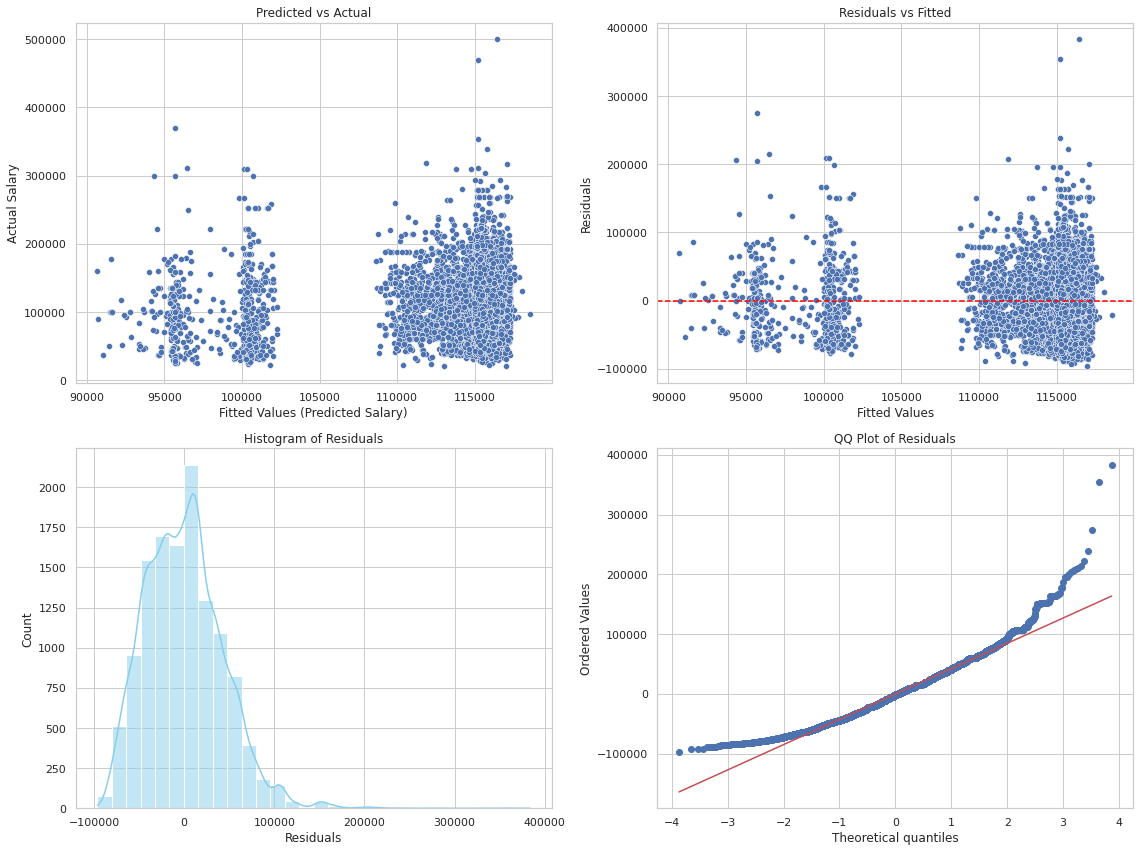

In [6]:
#| eval: true
#| echo: false
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Load predictions from GLR model
# Select actual and predicted values
df_pred = summary.predictions.select("SALARY", "prediction").toPandas()

# Compute residuals and fitted values
df_pred["residuals"] = df_pred["SALARY"] - df_pred["prediction"]
df_pred["fitted"] = df_pred["prediction"]

# Standardized residuals
res_mean = df_pred["residuals"].mean()
res_std = df_pred["residuals"].std()
df_pred["std_residuals"] = (df_pred["residuals"] - res_mean) / res_std

# Square root of standardized residuals (for Scale-Location plot)
df_pred["sqrt_std_resid"] = np.sqrt(np.abs(df_pred["std_residuals"]))

# Set up the 2x2 grid of diagnostic plots
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Plot 1: Predicted vs Actual
plt.subplot(2, 2, 1)
sns.scatterplot(x="fitted", y="SALARY", data=df_pred)
plt.xlabel("Fitted Values (Predicted Salary)")
plt.ylabel("Actual Salary")
plt.title("Predicted vs Actual")

# Plot 2: Residuals vs Fitted
plt.subplot(2, 2, 2)
sns.scatterplot(x="fitted", y="residuals", data=df_pred)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

# Plot 3: Histogram of Residuals
plt.subplot(2, 2, 3)
sns.histplot(df_pred["residuals"], kde=True, bins=30, color="skyblue")
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")

# Plot 4: QQ Plot of Residuals
plt.subplot(2, 2, 4)
stats.probplot(df_pred["residuals"], dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")

plt.tight_layout()
plt.savefig("_output/glr_diagnostic_classic.png")
plt.show()


# Evaluation

The evaluation of the model is crucial to understand its performance. In this section, we will calculate and visualize the following metrics:
1. **R² (Coefficient of Determination)**: Indicates how well the model explains the variance in the target variable.
2. **RMSE (Root Mean Squared Error)**: Measures the average magnitude of the errors between predicted and actual values.

In [ ]:
#| eval: true
#| echo: false
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, pow, sqrt, avg
import numpy as np
from math import sqrt

# Make predictions on test data
pred_glr = lr_model.transform(test_data)

# R² (Coefficient of Determination)
r2_eval = RegressionEvaluator(predictionCol="prediction", labelCol="SALARY", metricName="r2")
r2 = r2_eval.evaluate(pred_glr)

# Number of observations (n)
n = pred_glr.count()

# Number of parameters (k), including intercept
k = len(lr_model.coefficients) + 1

# Residual Sum of Squares (RSS)
rss = pred_glr.select(pow(col("SALARY") - col("prediction"), 2).alias("squared_error")).agg({"squared_error": "sum"}).collect()[0][0]

# AIC Calculation
aic = n * np.log(rss / n) + 2 * k

# BIC Calculation
bic = n * np.log(rss / n) + k * np.log(n)

# RMSE
residuals_df = pred_glr.withColumn("squared_error", pow(col("SALARY") - col("prediction"), 2))
mse = residuals_df.agg(avg("squared_error")).collect()[0][0]
rmse = sqrt(mse)

# Print Results
print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"AIC (Akaike Information Criterion): {aic:.4f}")
print(f"BIC (Bayesian Information Criterion): {bic:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

R² (Coefficient of Determination): 0.0148
AIC (Akaike Information Criterion): 65702.8833
BIC (Bayesian Information Criterion): 65733.0500
RMSE (Root Mean Squared Error): 42510.5962


## Model Evaluation Plot

- Display the predicted vs actual salary plot with a red line indicating the ideal fit (y=x).
- Use `seaborn` or `matplotlib` to create the plot.
- Customize the plot with appropriate titles, labels, and legends.
- Describe the plot in a few sentences, highlighting key insights and observations.

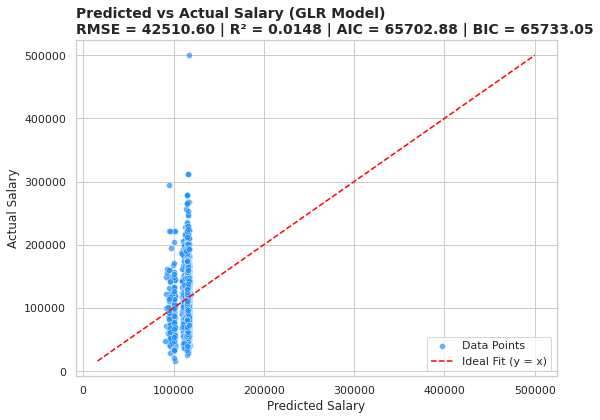

In [12]:
#| eval: true
#| echo: false
import matplotlib.pyplot as plt
import seaborn as sns

# Convert GLR predictions to pandas DataFrame
pandas_df = pred_glr.select("SALARY", "prediction").toPandas()

# Plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Scatter plot: Predicted vs Actual
sns.scatterplot(x="prediction", y="SALARY", data=pandas_df, alpha=0.7, color="dodgerblue", label="Data Points")

# Add red reference line y = x
max_val = max(pandas_df["SALARY"].max(), pandas_df["prediction"].max())
min_val = min(pandas_df["SALARY"].min(), pandas_df["prediction"].min())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Fit (y = x)")

# Labels and title
plt.xlabel("Predicted Salary", fontsize=12)
plt.ylabel("Actual Salary", fontsize=12)
plt.title(f"Predicted vs Actual Salary (GLR Model)\n"
          f"RMSE = {rmse:.2f} | R² = {r2:.4f} | AIC = {aic:.2f} | BIC = {bic:.2f}",
          loc="left", fontsize=14, fontweight="bold")
plt.legend()

plt.tight_layout()

# Save figure
plt.savefig("_output/glr_predicted_vs_actual.png", dpi=300)
plt.show()


# Submission {.unnumbered}
1. Save figures in the `_output/` folder.
2. Commit and push code and output files:
```bash
git add .
git commit -m "Add Lab 08 Salary Prediction models and output"
git push origin main
```
3. Submit your GitHub repository link.

# Resources {.unnumbered}
- [PySpark MLlib Docs](https://spark.apache.org/docs/latest/ml-guide.html)  
- [Seaborn Docs](https://seaborn.pydata.org/)  
- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)
